In [1]:
# ============================================
# 最重要：必须在 import torch 之前设置
# ============================================
import os

# 在导入任何 CUDA 相关库之前设置
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 使用 GPU 1
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# 然后再导入 PyTorch 和其他库
import gc
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.neighbors import kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 打印 GPU 信息
if torch.cuda.is_available():
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"当前使用 GPU: {torch.cuda.current_device()}")
    print(f"GPU 名称: {torch.cuda.get_device_name()}")
    print(
        f"总显存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
    print(f"当前可用显存: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

/home/ailab/miniconda3/envs/GNNTrain/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


使用设备: cuda
CUDA 版本: 11.8
当前使用 GPU: 0
GPU 名称: NVIDIA GeForce RTX 3080
总显存: 19.72 GB
当前可用显存: 19.49 GB


In [2]:
# ============================================
# 1. 加载数据
# ============================================
print("\n" + "=" * 60)
print("1. 加载数据")
print("=" * 60)

df = pd.read_csv("./data/xenium_for_gnn.csv")
print(f"数据形状: {df.shape}")

# 删除缺失值
df = df.dropna()
print(f"删除缺失值后数据形状: {df.shape}")


1. 加载数据
数据形状: (406611, 54)
删除缺失值后数据形状: (406611, 54)


In [3]:
# ============================================
# 2. 提取特征和标签
# ============================================
print("\n" + "=" * 60)
print("2. 提取特征和标签")
print("=" * 60)

# 提取空间坐标
coords = df[["x_centroid", "y_centroid"]].values
print(f"坐标矩阵形状: {coords.shape}")

# 提取PCA特征
pca_cols = [col for col in df.columns if col.startswith("PC_")]
features = df[pca_cols].values
print(f"PCA特征形状: {features.shape}")

# 标准化特征
scaler = StandardScaler()
features = scaler.fit_transform(features)

# 提取标签
labels_raw = df["predicted_cell_type"].values
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels_raw)
num_classes = len(label_encoder.classes_)
print(f"类别数: {num_classes}")

# 统计各类别样本数
class_counts = pd.Series(labels).value_counts().sort_index()
print(f"各类别样本数:")
for i, count in class_counts.items():
    print(f"  类别 {i}: {count}")


2. 提取特征和标签
坐标矩阵形状: (406611, 2)
PCA特征形状: (406611, 50)
类别数: 16
各类别样本数:
  类别 0: 3451
  类别 1: 22071
  类别 2: 6734
  类别 3: 2298
  类别 4: 2650
  类别 5: 51693
  类别 6: 32368
  类别 7: 2673
  类别 8: 18438
  类别 9: 37912
  类别 10: 47557
  类别 11: 25010
  类别 12: 11085
  类别 13: 50487
  类别 14: 55335
  类别 15: 36849


In [4]:
# ============================================
# 3. 构建空间邻接图（使用较小的k值避免内存问题）
# ============================================
print("\n" + "=" * 60)
print("3. 构建空间邻接图")
print("=" * 60)


def build_spatial_graph(coords, k=10):
    """构建空间邻接图"""
    adj_matrix = kneighbors_graph(
        coords, n_neighbors=k, mode="connectivity", include_self=False
    )
    edge_index, _ = from_scipy_sparse_matrix(adj_matrix)
    return edge_index


# 尝试不同的k值
k_values = [5, 10, 15]
for k in k_values:
    edge_index = build_spatial_graph(coords, k=k)
    print(
        f"k={k}: 边数量={edge_index.shape[1]}, 平均度={2 * edge_index.shape[1] / coords.shape[0]:.2f}"
    )

# 使用较小的k值减少内存占用
DEFAULT_K = 10
edge_index = build_spatial_graph(coords, k=DEFAULT_K)
print(f"\n使用 k={DEFAULT_K} 构建图")
print(f"边数量: {edge_index.shape[1]}")


3. 构建空间邻接图
k=5: 边数量=2033055, 平均度=10.00
k=10: 边数量=4066110, 平均度=20.00
k=15: 边数量=6099165, 平均度=30.00

使用 k=10 构建图
边数量: 4066110


In [5]:
# ============================================
# 4. 创建PyTorch Geometric数据对象
# ============================================
print("\n" + "=" * 60)
print("4. 创建PyTorch Geometric数据对象")
print("=" * 60)

# 转换为Tensor
x = torch.FloatTensor(features)
y = torch.LongTensor(labels)
edge_index = edge_index.to(torch.long)

# 创建数据对象
data = Data(x=x, edge_index=edge_index, y=y)

print(f"节点数: {data.num_nodes}")
print(f"特征维度: {data.num_features}")
print(f"边数: {data.num_edges}")
print(f"类别数: {num_classes}")


4. 创建PyTorch Geometric数据对象
节点数: 406611
特征维度: 50
边数: 4066110
类别数: 16


In [6]:
# ============================================
# 5. 划分数据集
# ============================================
print("\n" + "=" * 60)
print("5. 划分数据集")
print("=" * 60)

indices = np.arange(data.num_nodes)
train_val_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=labels, random_state=42
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, stratify=labels[train_val_idx], random_state=42
)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"训练集大小: {train_mask.sum().item()}")
print(f"验证集大小: {val_mask.sum().item()}")
print(f"测试集大小: {test_mask.sum().item()}")


5. 划分数据集
训练集大小: 243966
验证集大小: 81322
测试集大小: 81323


In [7]:
# ============================================
# 6. 定义改进的图神经网络模型
# ============================================
print("\n" + "=" * 60)
print("6. 定义图神经网络模型")
print("=" * 60)


class ImprovedGCN(nn.Module):
    """
    改进的GCN模型：
    1. 使用跳跃连接缓解过平滑
    2. 使用批归一化稳定训练
    3. 减少层数避免过平滑
    """

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3, num_layers=2):
        super(ImprovedGCN, self).__init__()
        self.num_layers = num_layers

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # 输入层
        self.convs.append(GCNConv(in_dim, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        # 隐藏层
        for i in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # 输出层
        self.convs.append(GCNConv(hidden_dim, out_dim))

        self.dropout = dropout

        # 跳跃连接投影（如果维度不匹配）
        self.skip_proj = nn.Linear(in_dim, hidden_dim) if num_layers >= 2 else None

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # 保存输入用于跳跃连接
        identity = x

        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

            # 跳跃连接
            if i == 0 and self.skip_proj is not None:
                x = x + self.skip_proj(identity)

        # 输出层
        x = self.convs[-1](x, edge_index)

        return F.log_softmax(x, dim=1)


class GraphSAGEWithNorm(nn.Module):
    """带批归一化的GraphSAGE模型"""

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3, num_layers=2):
        super(GraphSAGEWithNorm, self).__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        self.convs.append(SAGEConv(in_dim, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        for i in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.convs.append(SAGEConv(hidden_dim, out_dim))
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)

        return F.log_softmax(x, dim=1)


class LightGAT(nn.Module):
    """
    轻量级GAT模型：
    1. 使用较小的隐藏维度
    2. 减少注意力头数
    3. 使用跳跃连接
    """

    def __init__(self, in_dim, hidden_dim, out_dim, heads=4, dropout=0.3):
        super(LightGAT, self).__init__()

        self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)

        self.conv2 = GATConv(
            hidden_dim * heads, out_dim, heads=1, concat=False, dropout=dropout
        )

        self.dropout = dropout
        self.skip_proj = nn.Linear(in_dim, hidden_dim * heads)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # 第一层
        identity = self.skip_proj(x)
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = x + identity  # 跳跃连接
        x = F.dropout(x, p=self.dropout, training=self.training)

        # 第二层
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)


class MLPWithDropout(nn.Module):
    """多层感知机（基线模型）"""

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3, num_layers=2):
        super(MLPWithDropout, self).__init__()

        self.layers = nn.ModuleList()
        self.bns = nn.ModuleList()

        self.layers.append(nn.Linear(in_dim, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        for i in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.layers.append(nn.Linear(hidden_dim, out_dim))
        self.dropout = dropout

    def forward(self, data):
        x = data.x

        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.layers[-1](x)

        return F.log_softmax(x, dim=1)


6. 定义图神经网络模型


In [8]:
# ============================================
# 7. 训练函数
# ============================================
print("\n" + "=" * 60)
print("7. 模型训练")
print("=" * 60)


def train_model(model, data, optimizer, epochs=200, patience=20, verbose=True):
    """训练模型"""
    model = model.to(device)
    data = data.to(device)

    best_val_acc = 0
    best_model_state = None
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # 训练阶段
        model.train()
        optimizer.zero_grad()

        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # 计算训练准确率
        pred = out.argmax(dim=1)
        train_acc = (
            (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
        )

        # 验证阶段
        model.eval()
        with torch.no_grad():
            out = model(data)
            val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask])
            val_acc = (
                (pred[data.val_mask] == data.y[data.val_mask]).float().mean().item()
            )

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # 早停检查
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"  早停于 epoch {epoch+1}")
            break

        # 打印训练信息
        if verbose and (epoch + 1) % 20 == 0:
            print(
                f"  Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.4f}"
            )

    # 加载最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    if verbose:
        print(f"\n最佳验证结果: Val Acc: {best_val_acc:.4f}")

    return model, train_losses, val_losses, train_accs, val_accs


def evaluate_model(model, data):
    """评估模型"""
    model.eval()
    data = data.to(device)

    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)

        test_pred = pred[data.test_mask].cpu().numpy()
        test_true = data.y[data.test_mask].cpu().numpy()

        test_acc = accuracy_score(test_true, test_pred)
        test_f1 = f1_score(test_true, test_pred, average="macro")

        return test_acc, test_f1, test_pred, test_true


7. 模型训练


In [9]:
# ============================================
# 8. 模型对比实验
# ============================================
print("\n" + "=" * 60)
print("8. 模型对比实验")
print("=" * 60)

# 模型配置
configs = {
    "MLP": {
        "model_class": MLPWithDropout,
        "params": {"hidden_dim": 128, "dropout": 0.3, "num_layers": 2},
    },
    "GCN_Improved": {
        "model_class": ImprovedGCN,
        "params": {"hidden_dim": 128, "dropout": 0.3, "num_layers": 2},
    },
    "GraphSAGE": {
        "model_class": GraphSAGEWithNorm,
        "params": {"hidden_dim": 128, "dropout": 0.3, "num_layers": 2},
    },
}

in_dim = data.num_features
out_dim = num_classes

results = {}
models = {}

for model_name, config in configs.items():
    print(f"\n{'-'*50}")
    print(f"训练 {model_name} 模型")
    print(f"{'-'*50}")

    # 创建模型
    model = config["model_class"](in_dim, **config["params"], out_dim=out_dim)
    print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")

    # 优化器
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    # 训练
    trained_model, train_losses, val_losses, train_accs, val_accs = train_model(
        model, data, optimizer, epochs=200, patience=30, verbose=True
    )

    # 评估
    test_acc, test_f1, test_pred, test_true = evaluate_model(trained_model, data)

    results[model_name] = {
        "test_acc": test_acc,
        "test_f1": test_f1,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_pred": test_pred,
        "test_true": test_true,
    }
    models[model_name] = trained_model

    print(f"\n{model_name} 测试结果:")
    print(f"  准确率: {test_acc:.4f}")
    print(f"  Macro F1: {test_f1:.4f}")

# 尝试训练轻量级GAT（如果内存允许）
print(f"\n{'-'*50}")
print(f"训练 LightGAT 模型")
print(f"{'-'*50}")

try:
    model = LightGAT(in_dim, hidden_dim=64, out_dim=out_dim, heads=4, dropout=0.3)
    print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    trained_model, train_losses, val_losses, train_accs, val_accs = train_model(
        model, data, optimizer, epochs=1000, patience=30, verbose=True
    )

    test_acc, test_f1, test_pred, test_true = evaluate_model(trained_model, data)

    results["LightGAT"] = {
        "test_acc": test_acc,
        "test_f1": test_f1,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_pred": test_pred,
        "test_true": test_true,
    }
    models["LightGAT"] = trained_model

    print(f"\nLightGAT 测试结果:")
    print(f"  准确率: {test_acc:.4f}")
    print(f"  Macro F1: {test_f1:.4f}")

except RuntimeError as e:
    print(f"LightGAT 训练失败 (内存不足): {e}")


8. 模型对比实验

--------------------------------------------------
训练 MLP 模型
--------------------------------------------------
模型参数量: 8,848
  Epoch  20/200 | Train Loss: 0.7281 | Train Acc: 0.7889 | Val Loss: 0.7051 | Val Acc: 0.7869
  Epoch  40/200 | Train Loss: 0.4615 | Train Acc: 0.8368 | Val Loss: 0.4185 | Val Acc: 0.8346
  Epoch  60/200 | Train Loss: 0.4072 | Train Acc: 0.8497 | Val Loss: 0.3693 | Val Acc: 0.8467
  Epoch  80/200 | Train Loss: 0.3833 | Train Acc: 0.8563 | Val Loss: 0.3497 | Val Acc: 0.8524
  Epoch 100/200 | Train Loss: 0.3703 | Train Acc: 0.8599 | Val Loss: 0.3386 | Val Acc: 0.8564
  Epoch 120/200 | Train Loss: 0.3607 | Train Acc: 0.8629 | Val Loss: 0.3308 | Val Acc: 0.8589
  Epoch 140/200 | Train Loss: 0.3541 | Train Acc: 0.8652 | Val Loss: 0.3251 | Val Acc: 0.8603
  Epoch 160/200 | Train Loss: 0.3494 | Train Acc: 0.8663 | Val Loss: 0.3208 | Val Acc: 0.8635
  Epoch 180/200 | Train Loss: 0.3438 | Train Acc: 0.8688 | Val Loss: 0.3171 | Val Acc: 0.8644
  Epoch 200/200 |


9. 结果可视化


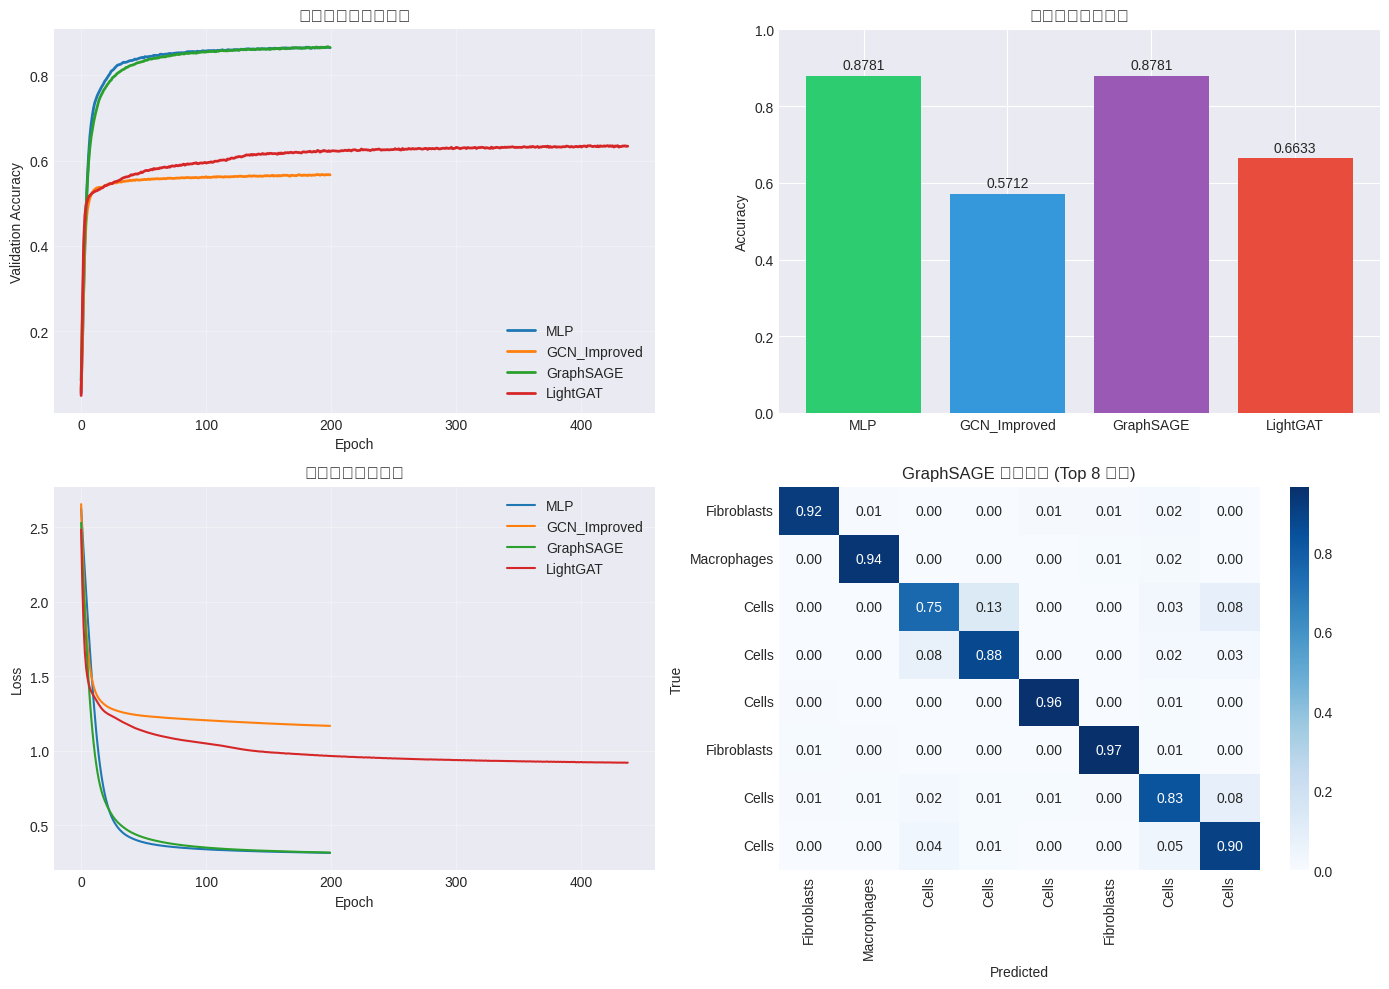

✅ 对比图已保存: ./results/model_comparison_improved.png


In [10]:
# ============================================
# 9. 结果对比可视化
# ============================================
print("\n" + "=" * 60)
print("9. 结果可视化")
print("=" * 60)

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 9.1 训练曲线对比
ax = axes[0, 0]
for model_name, result in results.items():
    ax.plot(result["val_accs"], label=f"{model_name}", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("验证准确率曲线对比")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# 9.2 测试准确率对比
ax = axes[0, 1]
model_names = list(results.keys())
test_accs = [results[m]["test_acc"] for m in model_names]
colors = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]
bars = ax.bar(model_names, test_accs, color=colors[: len(model_names)])
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("测试集准确率对比")
for bar, acc in zip(bars, test_accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# 9.3 损失曲线对比
ax = axes[1, 0]
for model_name, result in results.items():
    ax.plot(result["val_losses"], label=f"{model_name}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("验证损失曲线对比")
ax.legend()
ax.grid(True, alpha=0.3)

# 9.4 混淆矩阵（以最佳模型为例）
ax = axes[1, 1]
best_model_name = max(results.keys(), key=lambda x: results[x]["test_acc"])
best_result = results[best_model_name]

cm = confusion_matrix(best_result["test_true"], best_result["test_pred"])
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# 只显示前8个类别
top_8_classes = np.argsort(np.bincount(best_result["test_true"]))[-8:]
cm_subset = cm_norm[top_8_classes][:, top_8_classes]

class_labels = [label_encoder.classes_[i] for i in top_8_classes]
short_labels = [
    label.split()[-1][:12] if " " in label else label[:12] for label in class_labels
]

sns.heatmap(
    cm_subset,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=short_labels,
    yticklabels=short_labels,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"{best_model_name} 混淆矩阵 (Top 8 类别)")

plt.tight_layout()
plt.savefig("./results/model_comparison_improved.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 对比图已保存: ./results/model_comparison_improved.png")

In [11]:
# ============================================
# 10. 打印详细结果报告
# ============================================
print("\n" + "=" * 60)
print("10. 详细结果报告")
print("=" * 60)

print("\n📊 模型性能对比:")
print("-" * 50)
print(f"{'Model':<15} {'Test Acc':<12} {'Macro F1':<12}")
print("-" * 50)
for model_name, result in results.items():
    print(f"{model_name:<15} {result['test_acc']:<12.4f} {result['test_f1']:<12.4f}")
print("-" * 50)

best_model_name = max(results.keys(), key=lambda x: results[x]["test_acc"])
print(f"\n🏆 最佳模型: {best_model_name}")
print(f"   测试准确率: {results[best_model_name]['test_acc']:.4f}")
print(f"   Macro F1: {results[best_model_name]['test_f1']:.4f}")


10. 详细结果报告

📊 模型性能对比:
--------------------------------------------------
Model           Test Acc     Macro F1    
--------------------------------------------------
MLP             0.8781       0.8651      
GCN_Improved    0.5712       0.5410      
GraphSAGE       0.8781       0.8641      
LightGAT        0.6633       0.6307      
--------------------------------------------------

🏆 最佳模型: GraphSAGE
   测试准确率: 0.8781
   Macro F1: 0.8641



11. 空间可视化


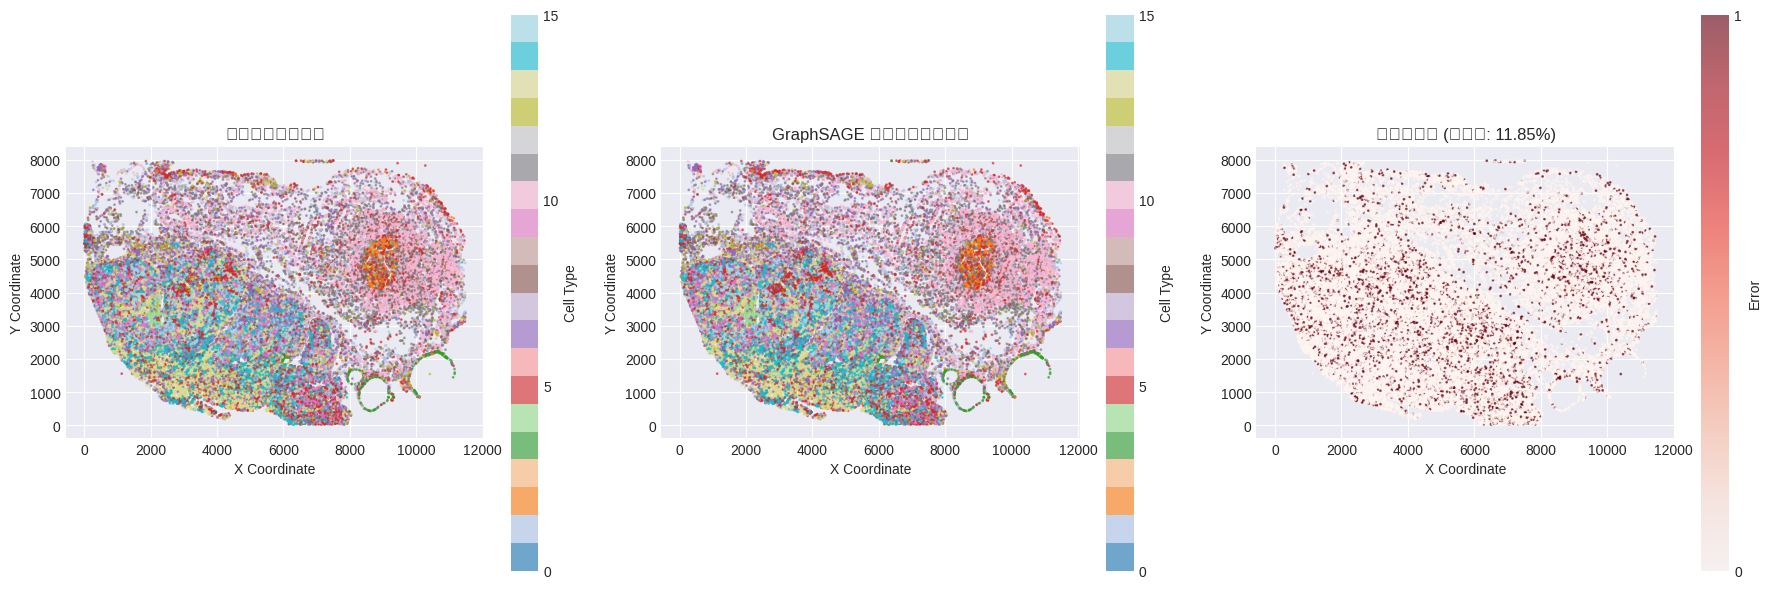

✅ 空间可视化图已保存: ./results/spatial_visualization_improved.png


In [12]:
# ============================================
# 11. 空间可视化
# ============================================
print("\n" + "=" * 60)
print("11. 空间可视化")
print("=" * 60)

best_model = models[best_model_name]
best_model.eval()
data = data.to(device)

with torch.no_grad():
    out = best_model(data)
    all_pred = out.argmax(dim=1).cpu().numpy()

true_labels = data.y.cpu().numpy()

# 创建空间可视化图（使用采样减少绘图点）
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 随机采样10%的点进行可视化
sample_idx = np.random.choice(len(coords), size=min(50000, len(coords)), replace=False)
coords_sampled = coords[sample_idx]
true_sampled = true_labels[sample_idx]
pred_sampled = all_pred[sample_idx]

# 11.1 真实标签空间分布
ax = axes[0]
scatter = ax.scatter(
    coords_sampled[:, 0],
    coords_sampled[:, 1],
    c=true_sampled,
    cmap="tab20",
    s=1,
    alpha=0.6,
)
ax.set_title("真实细胞类型分布")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="Cell Type", ticks=range(0, num_classes, 5))

# 11.2 预测标签空间分布
ax = axes[1]
scatter = ax.scatter(
    coords_sampled[:, 0],
    coords_sampled[:, 1],
    c=pred_sampled,
    cmap="tab20",
    s=1,
    alpha=0.6,
)
ax.set_title(f"{best_model_name} 预测细胞类型分布")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="Cell Type", ticks=range(0, num_classes, 5))

# 11.3 错误分类点
ax = axes[2]
errors = all_pred != true_labels
errors_sampled = errors[sample_idx]
error_colors = np.where(errors_sampled, 1, 0)
scatter = ax.scatter(
    coords_sampled[:, 0],
    coords_sampled[:, 1],
    c=error_colors,
    cmap="Reds",
    s=1,
    alpha=0.6,
)
ax.set_title(f"错误分类点 (错误率: {errors.mean():.2%})")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="Error", ticks=[0, 1])

plt.tight_layout()
plt.savefig(
    "./results/spatial_visualization_improved.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ 空间可视化图已保存: ./results/spatial_visualization_improved.png")

In [13]:
# ============================================
# 12. 保存结果
# ============================================
print("\n" + "=" * 60)
print("12. 保存结果")
print("=" * 60)

# 保存预测结果
predictions_df = pd.DataFrame(
    {
        "cell_id": df["cell_id"],
        "x_centroid": coords[:, 0],
        "y_centroid": coords[:, 1],
        "true_label": label_encoder.inverse_transform(true_labels),
        "predicted_label": label_encoder.inverse_transform(all_pred),
        "is_correct": (all_pred == true_labels),
    }
)
predictions_df.to_csv("./results/final_predictions_improved.csv", index=False)
print("✅ 预测结果已保存: ./results/final_predictions_improved.csv")

# 保存结果汇总
summary_df = pd.DataFrame(
    [
        {
            "Model": model_name,
            "Test_Accuracy": result["test_acc"],
            "Macro_F1": result["test_f1"],
        }
        for model_name, result in results.items()
    ]
)
summary_df.to_csv("./results/model_summary_improved.csv", index=False)
print("✅ 结果汇总已保存: ./results/model_summary_improved.csv")

print("\n" + "=" * 60)
print("实验完成！")
print("=" * 60)


12. 保存结果
✅ 预测结果已保存: ./results/final_predictions_improved.csv
✅ 结果汇总已保存: ./results/model_summary_improved.csv

实验完成！
